# Single-cell RNA-seq Analysis of PBMC 3k Dataset

This notebook performs an end-to-end analysis of the PBMC 3k single-cell RNA-seq dataset using Scanpy.

The workflow includes quality control, normalization, dimensionality reduction, clustering, visualization, and cell-type annotation based on canonical marker genes.

A simple machine learning extension is included to evaluate whether cluster identity can be predicted from PCA-reduced transcriptomic features.

### Environment

This notebook was run in Google Colab using Python, Scanpy, and scikit-learn.



## 1. Install required packages

This analysis uses the Python package **Scanpy**, which is a standard toolkit for single-cell RNA-seq analysis.  
I also install the Leiden clustering dependency, since it will be used later to identify groups of similar cells.

In [19]:
!pip install "scanpy[leiden]"

### What happened here?
This command installed Scanpy and its required dependencies in the Colab session.

- `scanpy` = main library for scRNA-seq analysis
- `[leiden]` = installs extra packages needed for Leiden clustering

Note: Because Colab sessions are temporary, this installation has to be run each time the notebook starts fresh.
Also mount Google Drive (only needed for Google Colab)

In [48]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    pass

Mounted at /content/drive


## 2. Import libraries

After installing Scanpy, I import the Python libraries used in this analysis.

- `scanpy` is used for single-cell analysis
- `pandas` is used for tables and data frames
- `numpy` is used for numerical operations
- `matplotlib` is used for plotting

I also print the Scanpy version to confirm the library loaded correctly.

In [20]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from importlib.metadata import version
print(version("scanpy"))

1.12.1


This confirms that the required libraries are available and ready to use.

## 3. Load a public scRNA-seq dataset

I load the PBMC 3k dataset, a commonly used public dataset of peripheral blood mononuclear cells.
This dataset is often used for learning standard single-cell analysis workflows.

The object created here is called an `AnnData` object, which stores:
- X (data matrix): the gene expression matrix (eg. cells x genes)
- obs (observations): A pandas DataFrame storing metadata about cells (e.g., cell types, sample IDs).
- var (Variables): A pandas DataFrame storing metadata about gene:s.

In [21]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [22]:
adata
adata.X.shape
adata.obs.head()
adata.var.head()

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945


### What this output shows
The dataset contains:
- rows = cells
- columns = genes

This is the starting point for the analysis.


## 4. Calculate quality-control (QC) metrics

Before analyzing the data, I calculate standard QC metrics for each cell.

These include:
- number of genes detected per cell (too many genes detected may indicate doublets)
- total counts per cell
- percentage of mitochondrial transcripts

These metrics help identify low-quality cells that may need to be removed before downstream analysis.


In [23]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head()


,n_genes_by_counts,total_counts,pct_counts_mt
index,,,
AAACATACAACCAC-1,781,2421.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,1.743085
AAACCGTGTATGCG-1,522,981.0,1.223242


I create a new column mt in .var that checks which genes start with "MT-" (mitochondrial genes). It calculates:
1. total_counts: total RNA counts in that cell
2. n_genes_by_counts: how many genes are detected
3. pct_counts_mt: % of RNA coming from mitochondrial genes

### Why this matters
Cells with very low numbers of genes or unusually high mitochondrial RNA can reflect damaged or poor-quality cells.
Removing these improves the reliability of downstream clustering and interpretation.

###4.1 Visualize QC metrics

I plot QC metrics to inspect the distribution of:
- genes detected per cell (n_genes_by_counts)
- total counts per cell (total_counts)
- mitochondrial percentage (pct_counts_mt)

These plots help choose filtering thresholds.

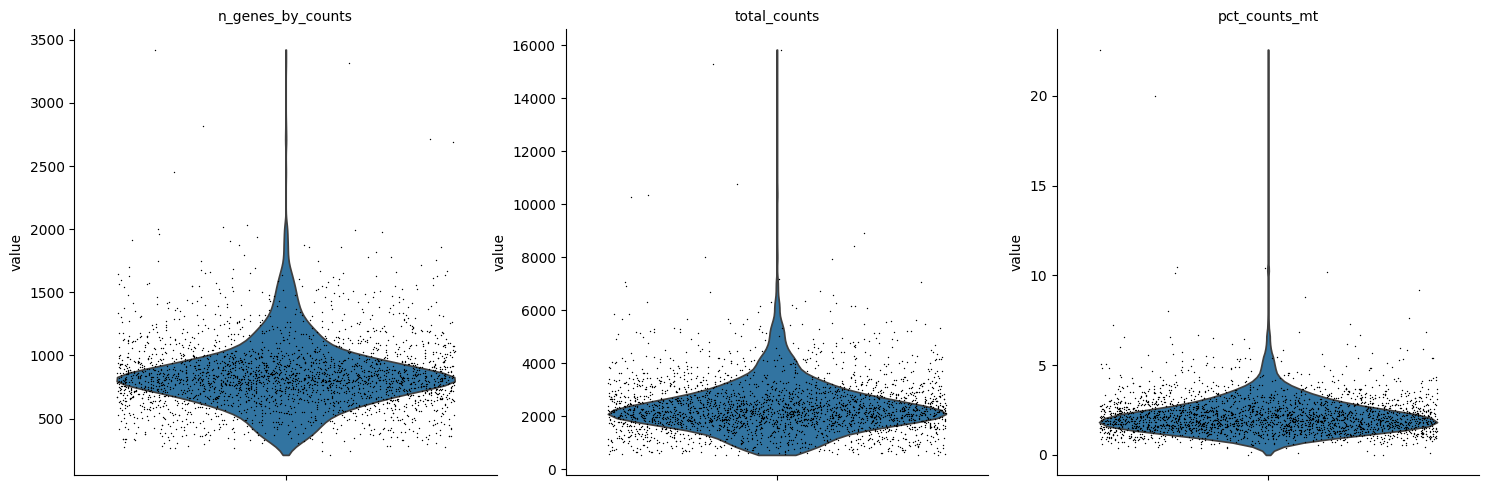

In [24]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

And scatter plots:

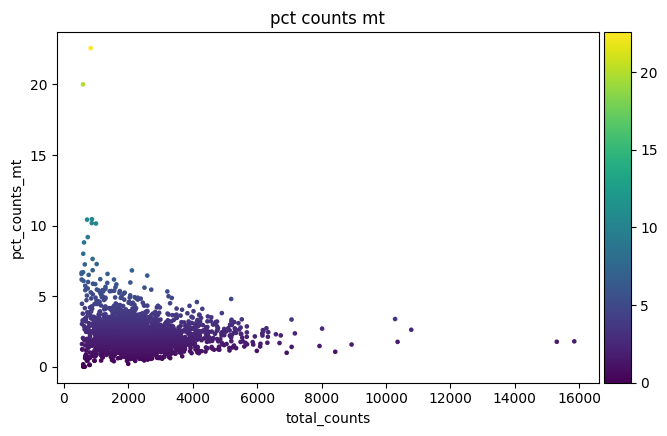

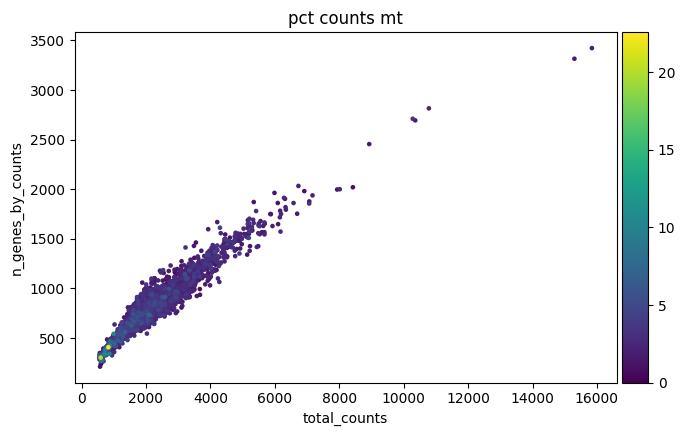

In [25]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", color="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

###How to interpret this
I am checking for cells that look poor quality, such as:

* very few genes detected

* unusually high counts

* high mitochondrial percentage

Those are common signs of poor-quality cells or technical artifacts in standard single-cell preprocessing.

###4.2 Filter low-quality cells and genes
Based on graphs, I set the following thresholds:
- n_genes_by_counts < 2500 because I don't want cells with too high count genes, aka too many genes detected (can include doublets)
- pct_counts_mt < 5 because above that number, the % of RNA coming from mitochondrial genes seems high for the total RNa counts in the cell (they tend to be very low so possibly dying cells)
- filter_genes(adata, min_cells=3) to keep only genes that are expressed in at least 3 cells. 3 avoids single-cell noise and keeps rare but real genes.

In [26]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()
sc.pp.filter_genes(adata, min_cells=3)

##5. Normalize the data

A standard step is library-size normalization followed by log transformation, so the data represents relative, comparabe gene expression across cells.
- Normalization converts raw counts, which are biased by sequencing depth into relative expression, which is comparable across cells. So you ask “What fraction of this cell’s transcriptome is each gene?” instead of “How many reads of each gene did we get?”
- Log transformation applies log(1 + x) to every value in my matrix, so it reduces the effect of extreme values, stabilizes variances and makes data more "normal like"

In [27]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()

This does:

normalize each cell to the same total counts
apply log transform to compress large values

## 6. Highly variable gene selection

Single-cell workflows usually focus on highly variable genes for PCA and clustering, helping identify different cell types/states. Highly variable genes are retained for downstream analysis.
1. Mean expression (mean): average expression across cells
- min_mean: remove genes that are too low → mostly noise
- max_mean: remove genes that are too high → housekeeping genes
2. Variance (var): how much gene expression changes across cells
3. Dispersion (disp): variance normalized by mean. min_disp keep genes that vary enough across cells, if disp's too low, the gene is not useful

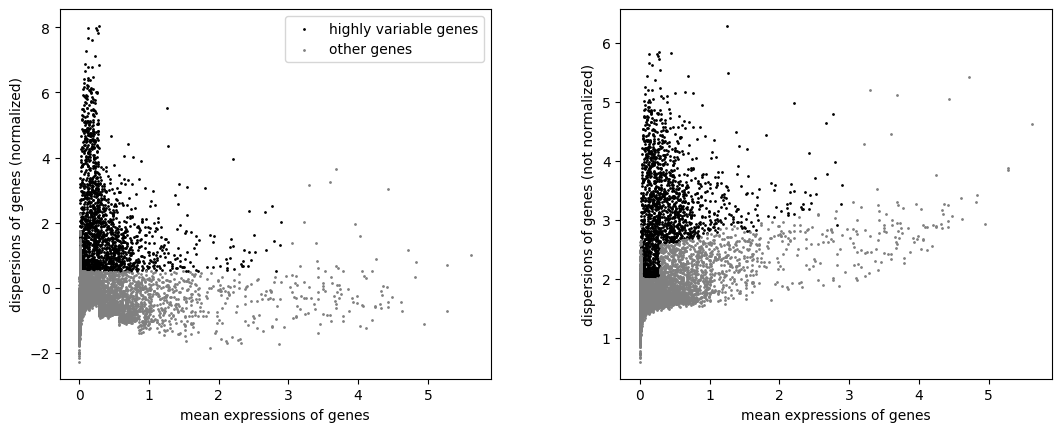

In [28]:
sc.pp.highly_variable_genes(adata,min_mean=0.0125,max_mean=3,min_disp=0.5)
sc.pl.highly_variable_genes(adata)

Then subset only the genes that are highly variable:

In [29]:
adata = adata[:, adata.var.highly_variable].copy()


##7. PCA

Scale the data and run PCA.
PCA is a standard dimension-reduction step (reduces ~2000 genes → ~20–50 components) before neighborhood graph construction and clustering.
- sc.pp.scale: For each gene subtracts the mean and divides by standard deviation. Why? cause genes have different ranges across all cells in the datasets and w/o scaling high-expressing genes would dominate the analysis.
- sc.tl.pca(adata) transforms my data into: cells x PCs(weighted combinations of genes)-->if a cell has a high PC1 value: it expresses genes associated with that pattern.
  - arpack: numerical algorithm to compute eigenvalues and eigen vectors efficiently
- sc.pl.pca_variance_ratio: It tells you how much of the total information (variation) in your data is captured by each principal component

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


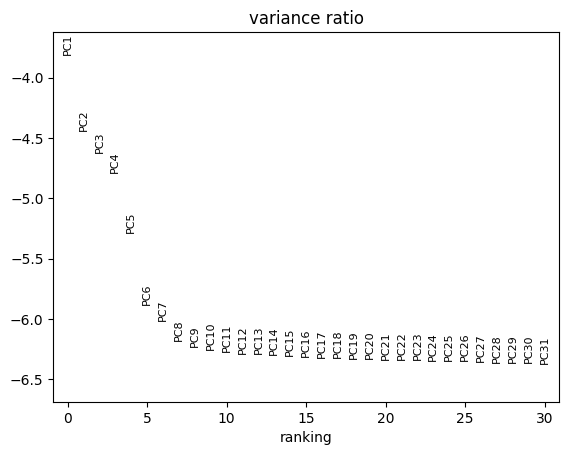

In [30]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True)

What this means:

- scaling puts genes on comparable ranges
- PCA compresses thousands of genes into a smaller number of components

What graph tells you: Plot with x-axis(PC number) and y-axis (explained variance ratio). The first PCs carry most infoLook for the elbow in plot, after that, PCs add little info.

##7. Neighbors+Leiden clustering
###7.1 Build the neighborhood graph

Clustering and UMAP in Scanpy are based on a nearest-neighbor graph constructed from PCA space. This step builds a graph that uses PCA coordinates and find nearest neighbors for each cellof similar cells. Builds a graph (network) where:
- nodes = cells
- edges = similarity.

Parameters:
- n_neighbors=10: How many neighbors each cell connects to. Standard default, captures local cell-type structure
- n_pcs=20 How many of the first PCA dimensions to use. 20 is good balance begween too few that miss structure and too many that adds noise. In this case, elbow in variance ratio graph is ~10, but later PCs can capture subtle cell states, rare populations and gradients (e.g., activation, differentiation)

In [31]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)

Cluster cells and compute UMAP:
I construct a nearest-neighbor graph and apply Leiden clustering to group similar cells.
Then I compute a UMAP projection to visualize the clusters in two dimensions.

In the UMAP plot:
- each dot represents one cell
- nearby cells have similar expression profiles
- colors represent cluster assignments

###7.2 Cluster the cells (Leiden)

After constructing a nearest-neighbor graph, I apply Leiden clustering algorithm on the cells to group them into clusters based on how similar they are. Leiden algortihm is preferred in scRNA-seq and it can handle large datasets. It maximizes modularity. It's goal is to:
- connections inside cluster ↑  
- connections between clusters ↓
- adata.obs["leiden"].value_counts(). Output:
  - leiden: Cluster #
  - count: counts how many cells are in each cluster.


In [32]:
sc.tl.leiden(adata)
adata.obs["leiden"].value_counts()

/tmp/ipykernel_17594/2897616483.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


,count
leiden,
0,575
1,566
2,437
3,344
4,305
5,199
6,159
7,37
8,16


This assigns each cell to a cluster.


##8. UMAP visualization

Then I compute a UMAP projection to visualize the clusters in two dimensions. UMAP is the usual 2D visualization to view clusters in single cell data

In the UMAP plot:
- each dot represents one cell
- nearby cells have similar expression profiles
- colors represent cluster assignments

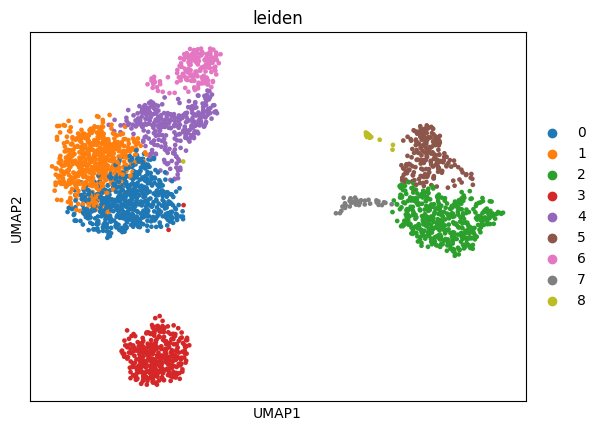

In [33]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=["leiden"])

Now you see the cells in 2D, colored by cluster.

##9. Marker gene identification

Next step is to identify which genes are more highly expressed compared with the other clusters. Differential expression is commonly used after clustering to identify marker genes for cell types.
- rank_genes_groups: This Scanpy function finds genes enriched in each group.
- method="wilcoxon": This tells Scanpy to use the Wilcoxon statistical test to compare gene expression. The Wilcoxon rank-sum test is a nonparametric test (does not assume data follows normal distribution). Instead of comparing raw means, it compares the ranks of the values. How it works? For cluster 0, it tests gene by gene--> Gene A: higher in cluster 0 than the rest of the clusters?, etc
**Could also use more powerful differential testing packages like DeSeq2, MAST, for python, diffxpy.

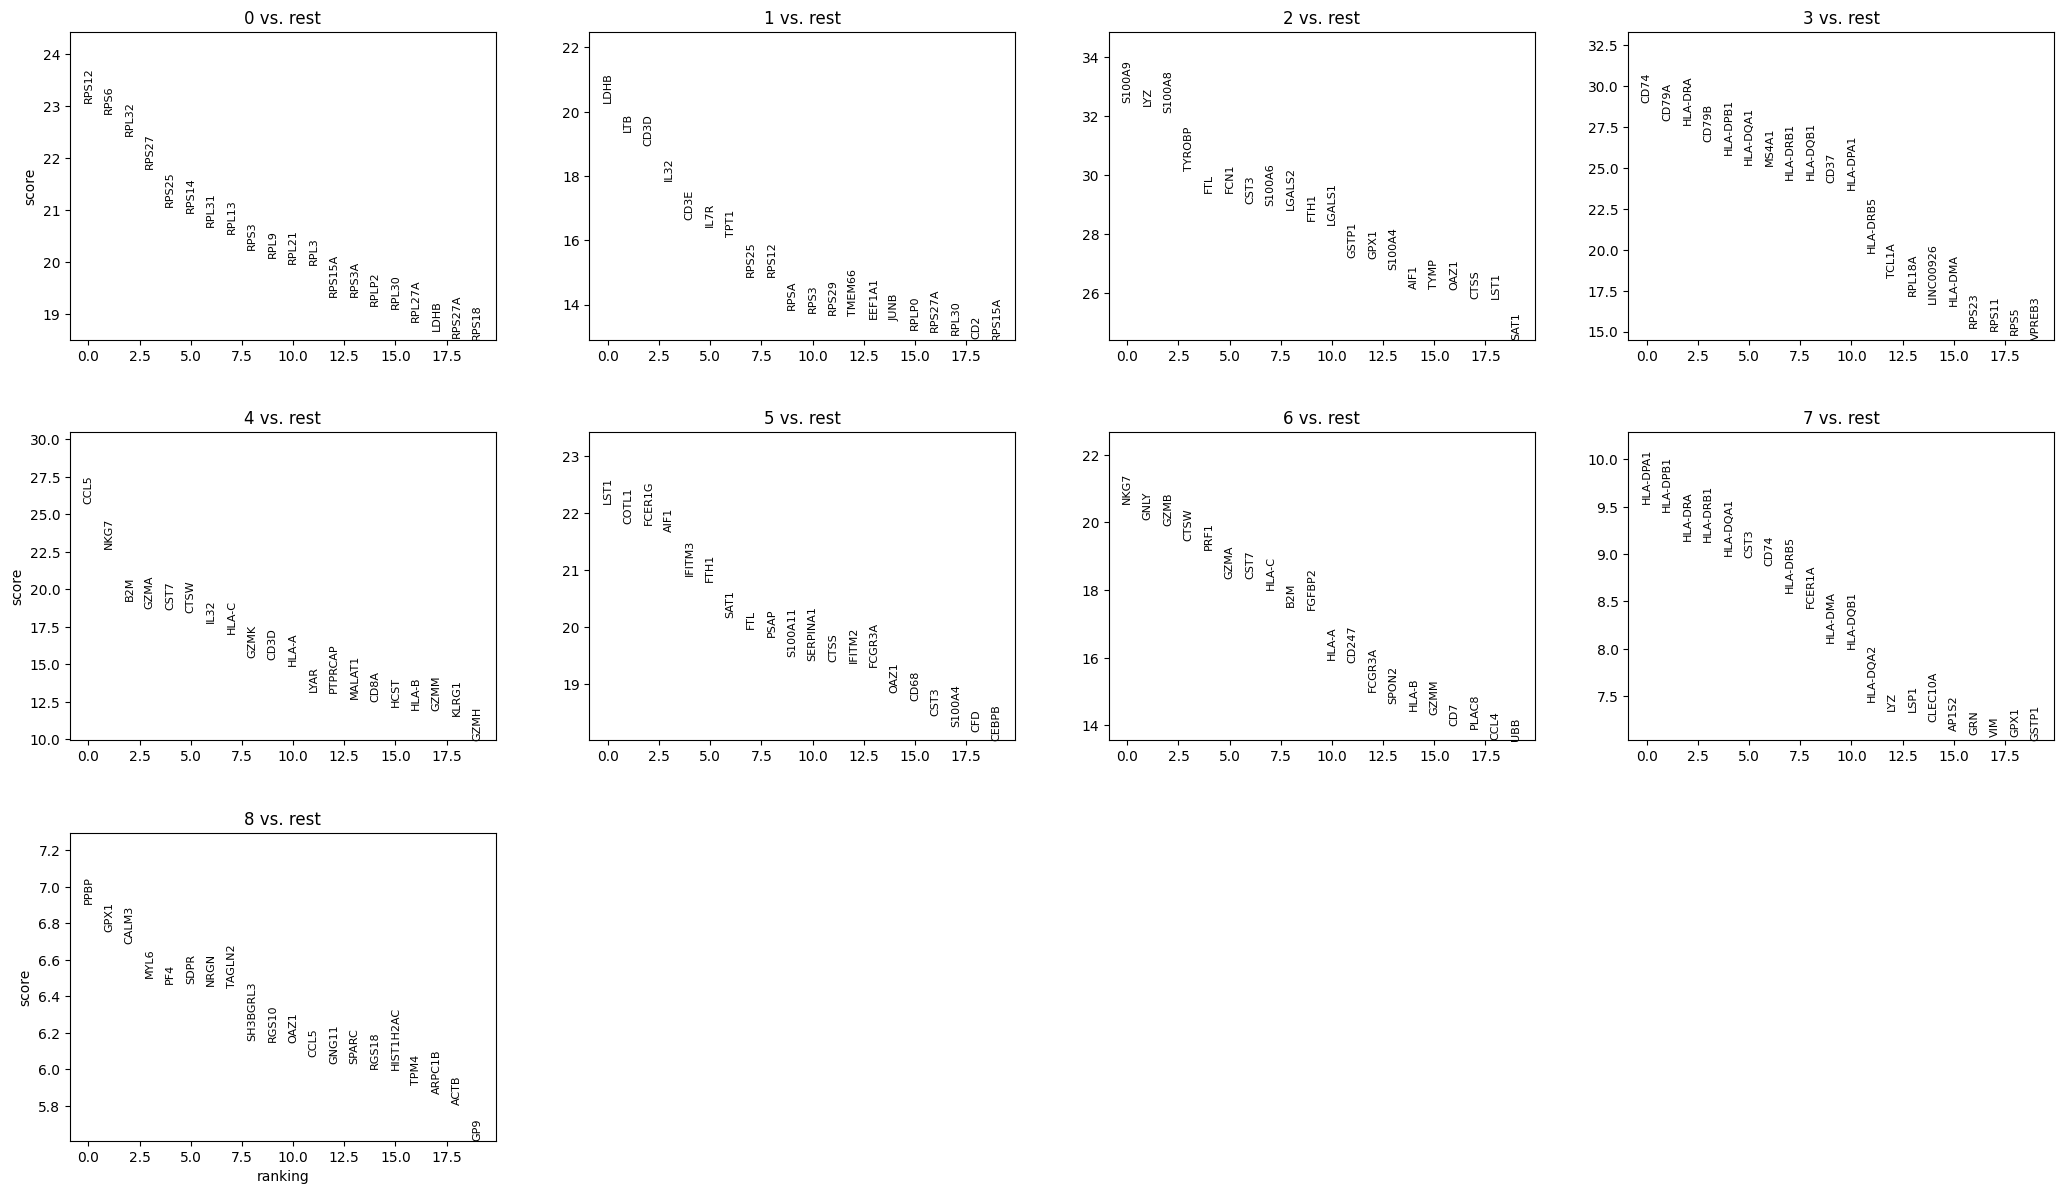

In [36]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon", use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

To inspect the results as a table:
- adata.uns[..: uns means unstructured annotations, basically a place where Scanpy stores analysis results.
- pd.DataFrame(...): creates a table
- {group: ... for group in groups}: This is a dictionary comprehension and it means: For each cluster, make one column

In [37]:
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names

markers = pd.DataFrame(
    {group: result["names"][group][:10] for group in groups}
)
markers

,0,1,2,3,4,5,6,7,8
0,RPS12,LDHB,S100A9,CD74,CCL5,LST1,NKG7,HLA-DPA1,PPBP
1,RPS6,LTB,LYZ,CD79A,NKG7,COTL1,GNLY,HLA-DPB1,GPX1
2,RPL32,CD3D,S100A8,HLA-DRA,B2M,FCER1G,GZMB,HLA-DRA,CALM3
3,RPS27,IL32,TYROBP,CD79B,GZMA,AIF1,CTSW,HLA-DRB1,MYL6
4,RPS25,CD3E,FTL,HLA-DPB1,CST7,IFITM3,PRF1,HLA-DQA1,PF4
5,RPS14,IL7R,FCN1,HLA-DQA1,CTSW,FTH1,GZMA,CST3,SDPR
6,RPL31,TPT1,CST3,MS4A1,IL32,SAT1,CST7,CD74,NRGN
7,RPL13,RPS25,S100A6,HLA-DRB1,HLA-C,FTL,HLA-C,HLA-DRB5,TAGLN2
8,RPS3,RPS12,LGALS2,HLA-DQB1,GZMK,PSAP,B2M,FCER1A,SH3BGRL3
9,RPL9,RPSA,FTH1,CD37,CD3D,S100A11,FGFBP2,HLA-DMA,RGS10


The table provides the top genes per cluster:
- Columns = clusters
- Rows = ranked genes ordered by differential expression

###9.1 Visualize known marker genes

For PBMC data, common marker genes can help infer rough cell types. Explore markers visually on the UMAP.

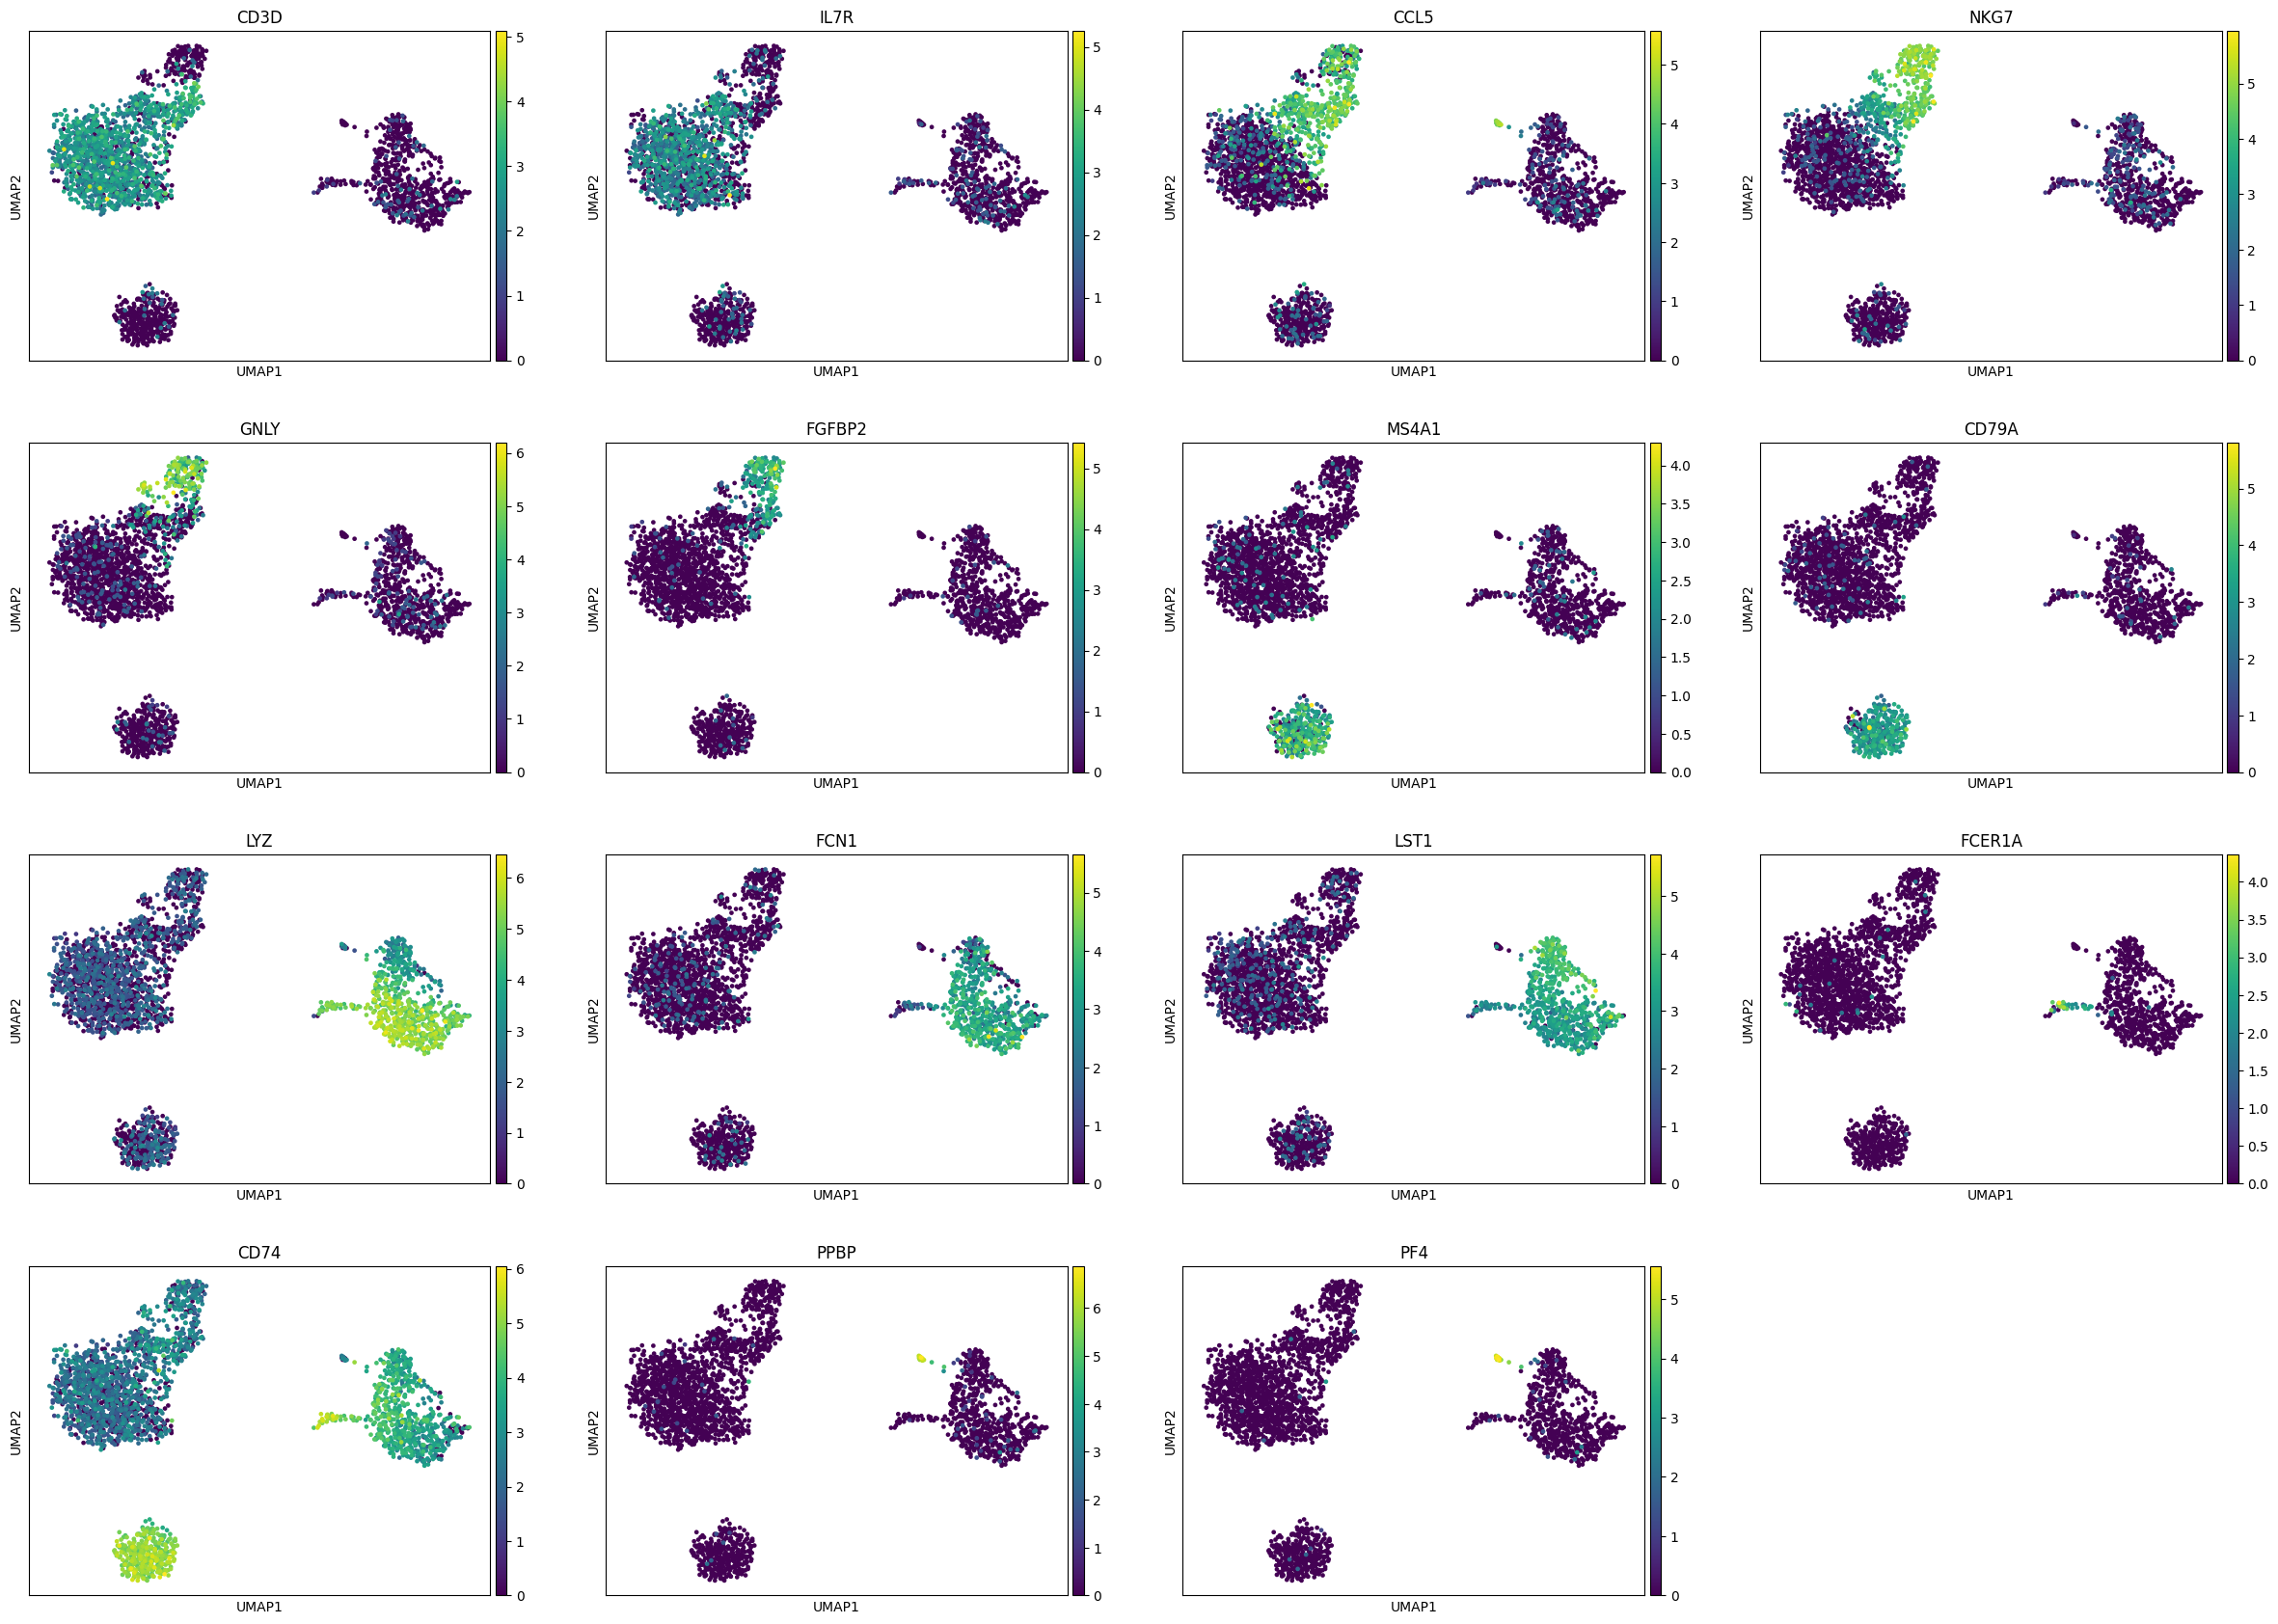

In [38]:
sc.pl.umap(
    adata,
    color=[
        "CD3D", "IL7R",      # T cells
        "CCL5", "NKG7",      # cytotoxic T / NK
        "GNLY", "FGFBP2",    # NK
        "MS4A1", "CD79A",    # B cells
        "LYZ", "FCN1", "LST1",  # monocytes
        "FCER1A", "CD74",    # dendritic cells
        "PPBP", "PF4"        # platelets
    ]
)

###9.2 Add cell type labels

In [39]:
adata.obs["cell_type"] = adata.obs["leiden"].map({
    "0": "Unresolved",
    "1": "IL7R+ CD4 T cells",
    "2": "Classical monocytes",
    "3": "B cells",
    "4": "Cytotoxic T cells",
    "5": "Non-classical/intermediate monocytes",
    "6": "NK cells",
    "7": "Dendritic cells",
    "8": "Platelets"
})

Clusters were annotated based on canonical marker genes. Distinct immune populations including T cells, B cells, NK cells, monocytes (classical and non-classical), dendritic cells, and platelets were identified. One ribosomal-dominant cluster remained unresolved.

##10. Final polished UMAP

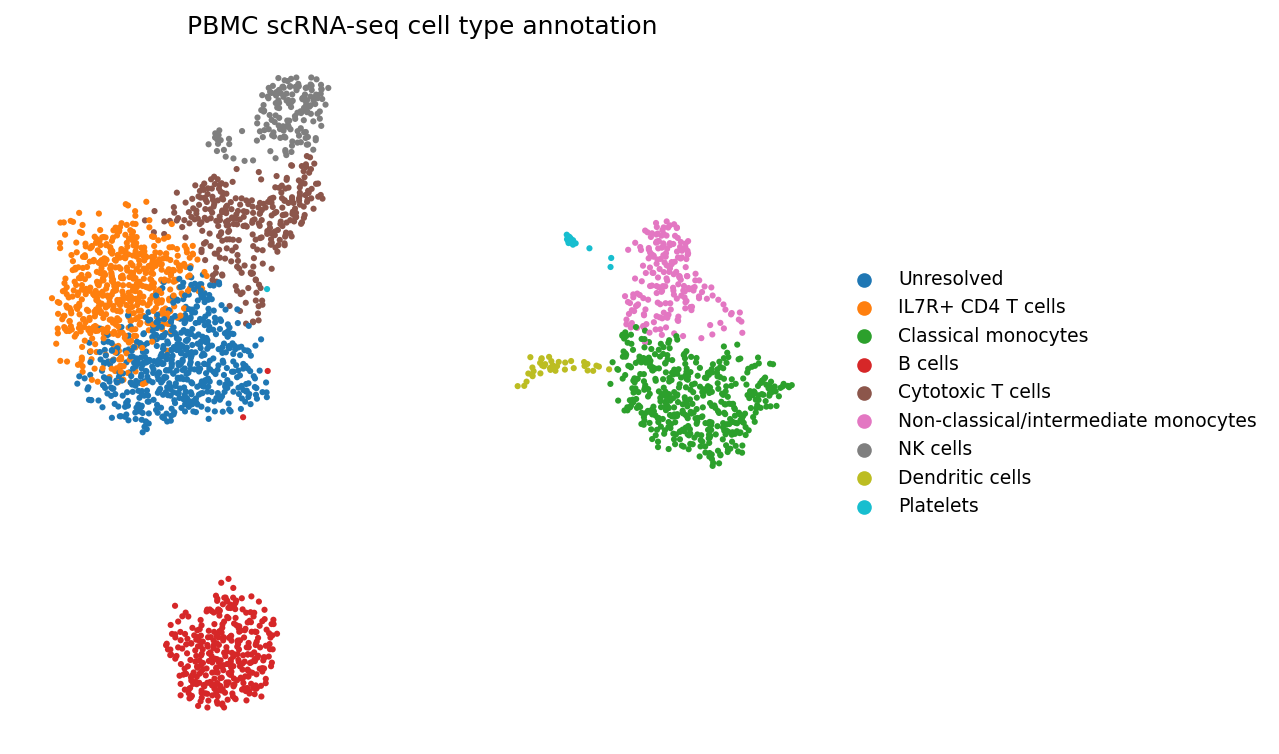

In [59]:
import os
os.makedirs("figures", exist_ok=True)

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (7, 6)

sc.pl.umap(
    adata,
    color="cell_type",
    palette="tab10",
    legend_fontsize=9,
    frameon=False,
    title="PBMC scRNA-seq cell type annotation",
    size=35,
    show=False
)

plt.savefig("figures/umap_cell_types.png", bbox_inches="tight", dpi=300)
plt.show()

In [60]:
from google.colab import files
files.download("figures/umap_cell_types.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###10.1 Marker validation figure

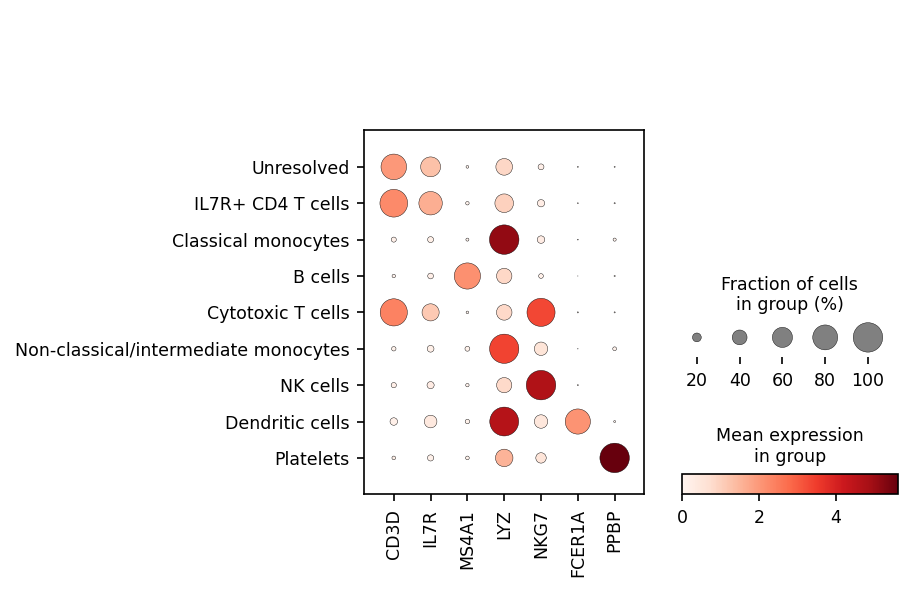

In [42]:
sc.pl.dotplot(
    adata,
    var_names=["CD3D","IL7R","MS4A1","LYZ","NKG7","FCER1A","PPBP"],
    groupby="cell_type"
)

This graph shows:
- each cell type expresses expected markers
- confirms annotation scientifically

Save the analyzed object:

In [50]:
adata.write('/content/drive/MyDrive/Colab_Notebooks/pbmc3k_analysis.h5ad')

##11. Results & Interpretation

Cells were clustered using the Leiden algorithm and visualized with UMAP.

Based on marker gene expression, the following cell types were identified:

- CD4 T cells (CD3D, IL7R)
- Cytotoxic CD8 T cells (CCL5, GZMA)
- NK cells (GNLY, GZMB)
- B cells (MS4A1, CD79A)
- Classical monocytes (S100A8, S100A9, FCN1)
- Non-classical monocytes (LST1, AIF1)
- Dendritic cells (FCER1A, HLA genes)
- Platelets (PPBP, PF4)

One cluster was labeled as unresolved due to lack of clear marker expression.


# Machine Learning Extension: Predict cell type or cluster from gene expression

As a downstream analysis, I explored whether cell cluster identity can be predicted from transcriptomic features using a supervised machine learning approach (I trained a Random Forest classifier to predict Leiden cluster labels from PCA-reduced single-cell transcriptomic profiles).

This serves as a simple demonstration of how single-cell RNA-seq data can be integrated with standard ML workflows.



##1. Machine Learning Libraries

The following modules from scikit-learn are used:

- `train_test_split` for splitting the dataset  
- `RandomForestClassifier` for model training  
- `classification_report` and `accuracy_score` for evaluation  

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

##2. Feature and Label Selection

For this task:

- Features (`X`) consist of the first 20 PCA-reduced gene expression values for each cell
- Labels (`y`) correspond to Leiden cluster assignment for each cell
PCA is used to reduce dimensionality while preserving the most informative variation in the data.

In [52]:
X = adata.obsm["X_pca"][:, :20]
y = adata.obs["leiden"]

##3. Train-Test Split

The dataset is split into training and test sets:

- 80% of the data is used for training  
- 20% is used for evaluation  

Stratified sampling is used to preserve cluster proportions across splits.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

##4. Model Training

A Random Forest classifier is used for this task.

Random Forest is a tree-based ensemble model that is:

- robust to noise  
- easy to interpret  
- well-suited for tabular data  

The model is trained to predict cluster identity from PCA features.

In [54]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

##5. Model Evaluation

Model performance is evaluated using:

- Accuracy (overall prediction performance)  
- Precision, recall, and F1-score (per-cluster performance)  

These metrics help assess how well the model distinguishes between different cell populations.

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9318181818181818
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       115
           1       0.87      0.91      0.89       113
           2       0.92      1.00      0.96        88
           3       1.00      1.00      1.00        69
           4       0.95      0.92      0.93        61
           5       1.00      0.85      0.92        40
           6       1.00      0.97      0.98        32
           7       1.00      0.86      0.92         7
           8       1.00      0.67      0.80         3

    accuracy                           0.93       528
   macro avg       0.96      0.90      0.92       528
weighted avg       0.93      0.93      0.93       528



##6. Confusion Matrix

To better understand model performance, a confusion matrix was generated.

This visualization shows how often each cluster is correctly predicted versus misclassified, providing insight into which cell populations are more easily distinguished.

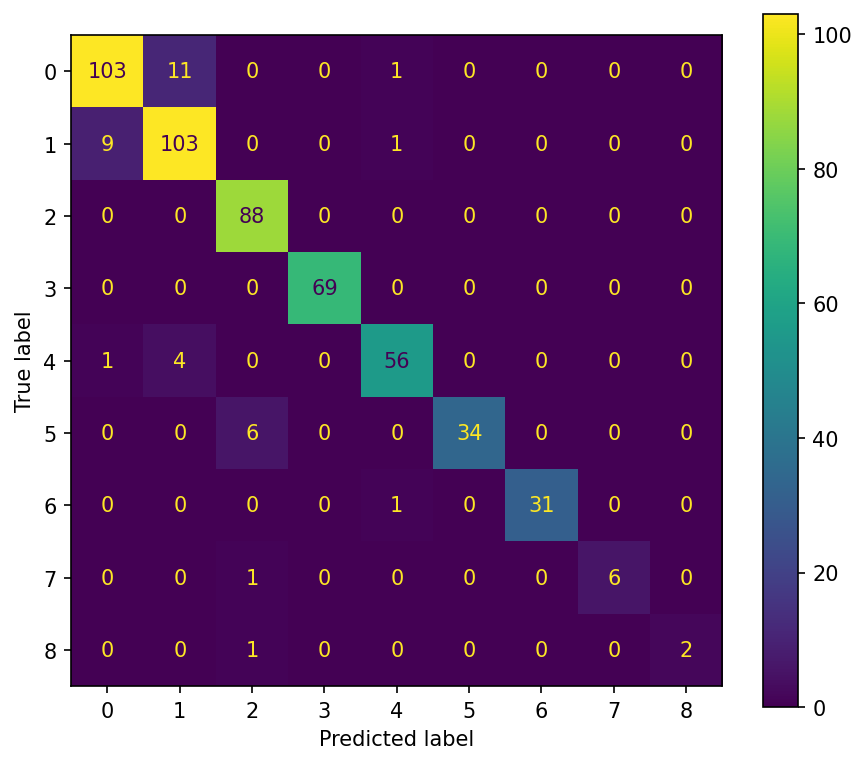

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.show()

The confusion matrix shows that most clusters are accurately classified, with high agreement between predicted and true labels.

Misclassifications tend to occur between biologically similar clusters, such as closely related T cell populations, which is expected given their similar transcriptional profiles.

##6.1 Label confusion matrix with cell types

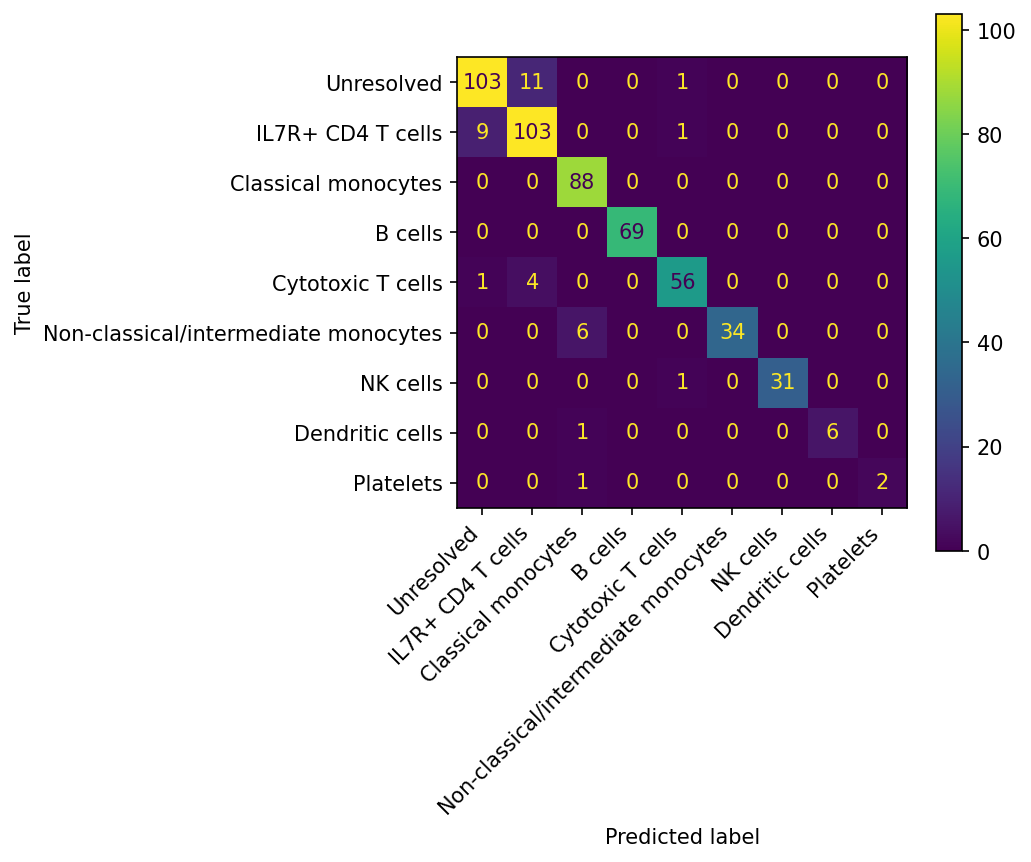

In [62]:
labels = adata.obs["cell_type"].cat.categories

ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    display_labels=labels
)

plt.xticks(rotation=45, ha="right") #rotate+align
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("figures/confusion_matrix_PBMC.png", bbox_inches="tight", dpi=300)
plt.show()

In [63]:
from google.colab import files
files.download("figures/confusion_matrix_PBMC.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##7. Results and Interpretation (Machine Learning)

The confusion matrix shows that most clusters are accurately classified, as indicated by strong diagonal values.

Misclassifications occur primarily between biologically similar clusters, such as closely related T cell populations and monocyte subtypes. This is expected given their similar transcriptional profiles.

Overall, the results indicate that the clusters identified through unsupervised analysis are well-separated and that their structure can be learned by a supervised model.